<a href="https://colab.research.google.com/github/varun4010/Customer_churn_project/blob/main/CustomerLeavingStop_latest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import joblib
import kagglehub
import numpy as np
import pandas as pd
import optuna
from optuna.samplers import TPESampler
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42

# --- load data ---
path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
df = pd.read_csv(os.path.join(path, "Customer-Churn-Records.csv"))
df.drop(["Complain", "RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)

y = df["Exited"]
df = df.drop("Exited", axis=1)

# --- feature engineering (same as the XGBoost version so the comparison is fair) ---
df["ZeroBalance"] = (df["Balance"] == 0).astype(int)
df["BalanceSalaryRatio"] = df["Balance"] / (df["EstimatedSalary"] + 1)
df["AgeBucket"] = pd.cut(
    df["Age"], bins=[17, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "60+"]
).astype(str)
df["TenureAgeRatio"] = df["Tenure"] / (df["Age"] + 1)
df["ProductsPerTenure"] = df["NumOfProducts"] / (df["Tenure"] + 1)

# ~4% of customers have Tenure=0, basically brand new signups -> flag it same as ZeroBalance
df["ZeroTenure"] = (df["Tenure"] == 0).astype(int)

cat_features = ["Geography", "Gender", "AgeBucket"]  # Card Type handled separately below, it's ordinal

CARD_TYPE_ORDER = {"SILVER": 0, "GOLD": 1, "PLATINUM": 2, "DIAMOND": 3}

# --- train/val/test split ---
xtr_full, xts, ytr_full, yts = train_test_split(
    df, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
xtr, xval, ytr, yval = train_test_split(
    xtr_full, ytr_full, test_size=0.2, stratify=ytr_full, random_state=RANDOM_STATE
)

num_neg = np.sum(ytr == 0)
num_pos = np.sum(ytr == 1)
estimated_weight = num_neg / num_pos


def preprocess(X):
    # ordinal encode card type instead of treating it as a plain category
    X = X.copy()
    X["CardTypeOrdinal"] = X["Card Type"].map(CARD_TYPE_ORDER)
    X = X.drop(columns=["Card Type"])

    # fillna before casting to str, otherwise real NaNs turn into the string "nan"
    for c in cat_features:
        X[c] = X[c].fillna("Missing").astype(str)

    return X


preprocessor = FunctionTransformer(preprocess)

# --- optuna tuning, only on xtr/ytr via CV, xval/xts untouched here ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def objective(trial):
    cb_params = {
        "iterations": trial.suggest_categorical("iterations", [300, 500, 800, 1200]),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 3, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "border_count": trial.suggest_categorical("border_count", [32, 64, 128, 254]),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, estimated_weight * 2, log=True),
        "loss_function": "Logloss",
        "eval_metric": "F1",
        "random_state": RANDOM_STATE,
        "verbose": False,
        "allow_writing_files": False,
        "thread_count": -1,
    }

    scores = []
    for train_idx, val_idx in cv.split(xtr, ytr):
        X_train_cv, X_val_cv = xtr.iloc[train_idx], xtr.iloc[val_idx]
        y_train_cv, y_val_cv = ytr.iloc[train_idx], ytr.iloc[val_idx]

        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("catboost", CatBoostClassifier(cat_features=cat_features, **cb_params)),
        ])
        pipe.fit(X_train_cv, y_train_cv)
        preds = pipe.predict(X_val_cv)
        scores.append(f1_score(y_val_cv, preds))

    return np.mean(scores)


optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=RANDOM_STATE))

print("Starting Optuna optimization (CatBoost)...")
study.optimize(objective, n_trials=60, show_progress_bar=True)

print(f"Best CV F1: {study.best_value:.4f}")
print("Best params:", study.best_params)

# --- fit final model on full training set ---
best_params = study.best_params.copy()
best_params.update({
    "loss_function": "Logloss",
    "eval_metric": "F1",
    "random_state": RANDOM_STATE,
    "verbose": False,
    "allow_writing_files": False,
    "thread_count": -1,
})

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("catboost", CatBoostClassifier(cat_features=cat_features, **best_params)),
])
final_pipeline.fit(xtr, ytr)

# check on validation set first, before touching test set
yval_pred = final_pipeline.predict(xval)
print(f"\nValidation F1: {f1_score(yval, yval_pred):.4f}")

# final test set evaluation, only run once
# F1 is the sole evaluation metric per competition rules -> plain .predict()
# at the sklearn default 0.5 threshold, no predict_proba / custom threshold involved
ypr = final_pipeline.predict(xts)

print(f"\nTest F1: {f1_score(yts, ypr):.4f}")
print(classification_report(yts, ypr, target_names=["Stayed (0)", "Churned (1)"]))

joblib.dump({"pipeline": final_pipeline}, "bank_churn_catboost_pipeline.joblib")
print("Saved pipeline to bank_churn_catboost_pipeline.joblib")

Using Colab cache for faster access to the 'bank-customer-churn' dataset.
Starting Optuna optimization (CatBoost)...


  0%|          | 0/60 [00:00<?, ?it/s]

Best CV F1: 0.6282
Best params: {'iterations': 800, 'learning_rate': 0.010211753133264504, 'depth': 6, 'l2_leaf_reg': 1.799629442281571, 'random_strength': 1.3495198637209393, 'bagging_temperature': 0.8000920381375523, 'border_count': 64, 'scale_pos_weight': 2.6341357526370577}

Validation F1: 0.6107

Test F1: 0.6421
              precision    recall  f1-score   support

  Stayed (0)       0.92      0.89      0.90      1592
 Churned (1)       0.61      0.68      0.64       408

    accuracy                           0.84      2000
   macro avg       0.76      0.78      0.77      2000
weighted avg       0.85      0.84      0.85      2000

Saved pipeline to bank_churn_catboost_pipeline.joblib


In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.3 MB/s eta 0:00:00


In [ ]:
import os
import joblib
import kagglehub
import numpy as np
import pandas as pd
import optuna
from optuna.samplers import TPESampler
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42

# load dataset
path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
df = pd.read_csv(os.path.join(path, "Customer-Churn-Records.csv"))

# Complain is basically a leaked version of the target (customers who complain
# almost always end up marked as churned), so it goes along with the id columns
df.drop(["Complain", "RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)

y = df["Exited"]
df = df.drop("Exited", axis=1)

# feature engineering
df["ZeroBalance"] = (df["Balance"] == 0).astype(int)
df["BalanceSalaryRatio"] = df["Balance"] / (df["EstimatedSalary"] + 1)
df["AgeBucket"] = pd.cut(
    df["Age"], bins=[17, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "60+"]
).astype(str)
df["TenureAgeRatio"] = df["Tenure"] / (df["Age"] + 1)
df["ProductsPerTenure"] = df["NumOfProducts"] / (df["Tenure"] + 1)
df["ZeroTenure"] = (df["Tenure"] == 0).astype(int)  # brand new customers, ~4% of the data

cat_features = ["Geography", "Gender", "AgeBucket"]
CARD_TYPE_ORDER = {"SILVER": 0, "GOLD": 1, "PLATINUM": 2, "DIAMOND": 3}

# split into train / val / test, val is carved out of the train portion
xtr_full, xts, ytr_full, yts = train_test_split(
    df, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
xtr, xval, ytr, yval = train_test_split(
    xtr_full, ytr_full, test_size=0.2, stratify=ytr_full, random_state=RANDOM_STATE
)

estimated_weight = np.sum(ytr == 0) / np.sum(ytr == 1)


def preprocess(X):
    X = X.copy()
    X["CardTypeOrdinal"] = X["Card Type"].map(CARD_TYPE_ORDER)
    X = X.drop(columns=["Card Type"])
    for c in cat_features:
        X[c] = X[c].fillna("Missing").astype(str)
    return X


preprocessor = FunctionTransformer(preprocess)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def objective(trial):
    params = {
        "iterations": trial.suggest_categorical("iterations", [300, 500, 800, 1200]),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 3, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "border_count": trial.suggest_categorical("border_count", [32, 64, 128, 254]),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, estimated_weight * 2, log=True),
        "loss_function": "Logloss",
        "eval_metric": "F1",
        "random_state": RANDOM_STATE,
        "verbose": False,
        "allow_writing_files": False,
        "thread_count": -1,
    }

    fold_scores = []
    for train_idx, val_idx in cv.split(xtr, ytr):
        X_train_cv, X_val_cv = xtr.iloc[train_idx], xtr.iloc[val_idx]
        y_train_cv, y_val_cv = ytr.iloc[train_idx], ytr.iloc[val_idx]

        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("catboost", CatBoostClassifier(cat_features=cat_features, **params)),
        ])
        pipe.fit(X_train_cv, y_train_cv)
        preds = pipe.predict(X_val_cv)
        fold_scores.append(f1_score(y_val_cv, preds))

    return np.mean(fold_scores)


optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=RANDOM_STATE))

print("running optuna search (catboost)...")
study.optimize(objective, n_trials=60, show_progress_bar=True)

print(f"best cv f1: {study.best_value:.4f}")
print("best params:", study.best_params)

best_params = study.best_params.copy()
best_params.update({
    "loss_function": "Logloss",
    "eval_metric": "F1",
    "random_state": RANDOM_STATE,
    "verbose": False,
    "allow_writing_files": False,
    "thread_count": -1,
})

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("catboost", CatBoostClassifier(cat_features=cat_features, **best_params)),
])
final_pipeline.fit(xtr, ytr)

# sanity check on val before touching test
yval_pred = final_pipeline.predict(xval)
print(f"validation f1: {f1_score(yval, yval_pred):.4f}")

# test set only touched here, once. f1 at the default 0.5 threshold is the
# only metric we're reporting, per the competition rules
ypr = final_pipeline.predict(xts)
print(f"test f1: {f1_score(yts, ypr):.4f}")

joblib.dump({"pipeline": final_pipeline}, "bank_churn_catboost_pipeline.joblib")
print("saved pipeline -> bank_churn_catboost_pipeline.joblib")

Using Colab cache for faster access to the 'bank-customer-churn' dataset.
running optuna search (catboost)...


  0%|          | 0/60 [00:00<?, ?it/s]

best cv f1: 0.6282
best params: {'iterations': 800, 'learning_rate': 0.010211753133264504, 'depth': 6, 'l2_leaf_reg': 1.799629442281571, 'random_strength': 1.3495198637209393, 'bagging_temperature': 0.8000920381375523, 'border_count': 64, 'scale_pos_weight': 2.6341357526370577}
validation f1: 0.6107
test f1: 0.6421
saved pipeline -> bank_churn_catboost_pipeline.joblib


In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 22.1 MB/s eta 0:00:00


In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
import sklearn.preprocessing
!pip install ydata-profiling
from ydata_profiling import ProfileReport

path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
r=os.path.join(path,'Customer-Churn-Records.csv')
df=pd.read_csv(r)
df.drop(['Complain','RowNumber','CustomerId','Surname'],inplace=True,axis=1)
profile = ProfileReport(df, title="My Data Profiling Report")
profile.to_file("output.html")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 1.3 MB/s eta 0:00:00


/tmp/ipykernel_844/245739494.py:7: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Using Colab cache for faster access to the 'bank-customer-churn' dataset.


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:00<00:00, 36.59it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:

import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,classification_report
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
r=os.path.join(path,'Customer-Churn-Records.csv')
df=pd.read_csv(r)
df.drop(['Complain','RowNumber','CustomerId','Surname'],inplace=True,axis=1)
y=df['Exited']
df=df.drop(['Exited'],axis=1)
t=ColumnTransformer(transformers=[('t1',StandardScaler(),['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary','Point Earned']),('t2',OneHotEncoder(drop='first',sparse_output=False),['Geography','Gender']),('t3',OrdinalEncoder(categories=[['SILVER', 'GOLD', 'PLATINUM', 'DIAMOND']]),['Card Type'])],remainder='passthrough')
xtr,xts,ytr,yts=train_test_split(df,y,test_size=0.2,random_state=42)
xtr=t.fit_transform(xtr)
xts=t.transform(xts)
pr=DecisionTreeClassifier(max_depth=8 ,min_samples_leaf=5)
pr.fit(xtr,ytr)
ypr=pr.predict(xts)
d=classification_report(ypr,yts)
print(d)



Using Colab cache for faster access to the 'bank-customer-churn' dataset.
              precision    recall  f1-score   support

           0       0.94      0.88      0.91      1727
           1       0.47      0.67      0.55       273

    accuracy                           0.85      2000
   macro avg       0.70      0.77      0.73      2000
weighted avg       0.88      0.85      0.86      2000



Using Colab cache for faster access to the 'bank-customer-churn' dataset.


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:01<00:00, 12.11it/s]


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x792f01143100> (for post_execute):


KeyboardInterrupt: 

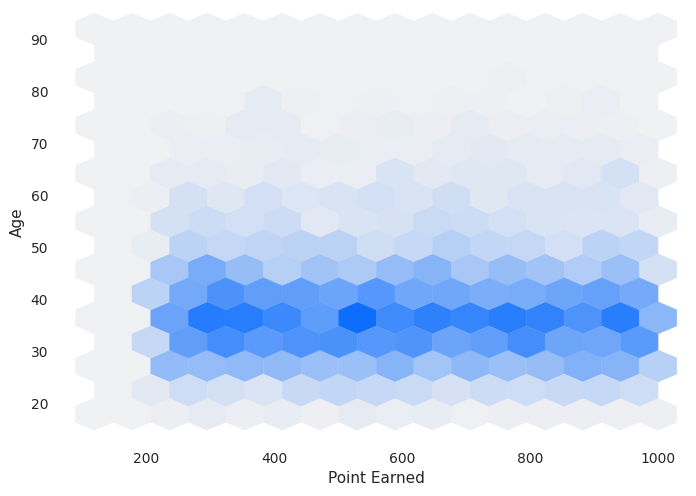

In [ ]:
import os
import kagglehub
import pandas as pd
from sklearn.model_selection import train_test_split
from ydata_profiling import ProfileReport

RANDOM_STATE = 42


path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
r = os.path.join(path, 'Customer-Churn-Records.csv')
df = pd.read_csv(r)
df.drop(['Complain', 'RowNumber', 'CustomerId', 'Surname'], inplace=True, axis=1)

y = df['Exited']
X = df.drop('Exited', axis=1)

# Same two-stage split used across the modeling pipelines, so the profile
# reflects exactly what the model trains on. xval and xts are produced here
# but never referenced again in this file -- nothing about them leaks into
# the profile's statistics, correlations, or alerts.
xtr_full, xts, ytr_full, yts = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
xtr, xval, ytr, yval = train_test_split(
    xtr_full, ytr_full, test_size=0.2, stratify=ytr_full, random_state=RANDOM_STATE
)

eda_df = xtr.copy()
eda_df['Exited'] = ytr.values

profile = ProfileReport(
    eda_df,
    title="Bank Customer Churn — Train Split EDA",
    explorative=True,
)
profile.to_file("output_train_eda.html")

print(f"Profiled {len(eda_df)} training rows only "
      f"({len(xval)} val / {len(xts)} test rows excluded from this report).")

In [ ]:
import os
import joblib
import kagglehub
import numpy as np
import pandas as pd
import optuna
from optuna.samplers import TPESampler
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, average_precision_score, f1_score
)
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42


# Load data

path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
r = os.path.join(path, 'Customer-Churn-Records.csv')
df = pd.read_csv(r)
df.drop(['Complain', 'RowNumber', 'CustomerId', 'Surname'], inplace=True, axis=1)

y = df['Exited']
df = df.drop(['Exited'], axis=1)


# Feature engineering (identical to the XGBoost pipeline, for a fair comparison)

df['ZeroBalance'] = (df['Balance'] == 0).astype(int)
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['AgeBucket'] = pd.cut(
    df['Age'], bins=[17, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+']
).astype(str)
df['TenureAgeRatio'] = df['Tenure'] / (df['Age'] + 1)
df['ProductsPerTenure'] = df['NumOfProducts'] / (df['Tenure'] + 1)

# NEW: explicit zero-inflation flag for Tenure. The ydata-profiling report
# on the training split flagged Tenure at 4.1% exact zeros -- brand-new
# customers (Tenure=0) are a structurally distinct segment, same reasoning
# that already justified ZeroBalance for the 36.2%-zero Balance column.
df['ZeroTenure'] = (df['Tenure'] == 0).astype(int)

# Nominal categoricals CatBoost should treat as unordered labels.
# Card Type is intentionally NOT in this list -- see ordinal encoding below.
cat_features = ['Geography', 'Gender', 'AgeBucket']

CARD_TYPE_ORDER = {'SILVER': 0, 'GOLD': 1, 'PLATINUM': 2, 'DIAMOND': 3}


# Stratified split (train / validation / test) — identical to the XGBoost script

xtr_full, xts, ytr_full, yts = train_test_split(
    df, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
xtr, xval, ytr, yval = train_test_split(
    xtr_full, ytr_full, test_size=0.2, stratify=ytr_full, random_state=RANDOM_STATE
)

num_neg = np.sum(ytr == 0)
num_pos = np.sum(ytr == 1)
estimated_weight = num_neg / num_pos


# ============================================================
# Preprocessing (enhanced)
#
# CatBoost needs true nominal categorical columns as strings -- but casting
# straight to str silently turns a real NaN into the literal string "nan",
# a category CatBoost can't tell apart from a genuine value. This dataset
# has zero missing values today (confirmed by the profiling report), but
# fillna() first makes that safe if this pipeline is ever reused on data
# that does have gaps -- a real missing value becomes its own explicit
# "Missing" category instead of an accidental fake "nan" one.
#
# Card Type has an intrinsic order (SILVER < GOLD < PLATINUM < DIAMOND),
# so it's ordinal-encoded to a numeric column instead of being passed
# through cat_features as an unordered label -- this also matches how the
# XGBoost pipeline encodes it, so both models see the same information
# about this feature for a fair comparison.
# ============================================================

def preprocess(X):
    X = X.copy()

    X['CardTypeOrdinal'] = X['Card Type'].map(CARD_TYPE_ORDER)
    X = X.drop(columns=['Card Type'])

    for c in cat_features:
        X[c] = X[c].fillna('Missing').astype(str)

    return X

preprocessor = FunctionTransformer(preprocess)


# Hyperparameter search with Optuna (Using Pipeline)
# NOTE: Only xtr/ytr (via StratifiedKFold CV) are used here. xval and xts
# are never touched during tuning, satisfying the test-set separation guideline.
# scale_pos_weight is searched rather than fixed, per the earlier discussion —
# since F1 is locked to the 0.5 threshold, this is the main lever for controlling
# the precision/recall tradeoff.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    cb_params = {
        'iterations': trial.suggest_categorical('iterations', [300, 500, 800, 1200]),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.0, 2.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_categorical('border_count', [32, 64, 128, 254]),
        'scale_pos_weight': trial.suggest_float(
            'scale_pos_weight', 1.0, estimated_weight * 2, log=True
        ),
        'loss_function': 'Logloss',
        'eval_metric': 'F1',
        'random_state': RANDOM_STATE,
        'verbose': False,
        'allow_writing_files': False,
        'thread_count': -1,
    }

    f1_scores = []
    for train_idx, val_idx in cv.split(xtr, ytr):
        X_train_cv, X_val_cv = xtr.iloc[train_idx], xtr.iloc[val_idx]
        y_train_cv, y_val_cv = ytr.iloc[train_idx], ytr.iloc[val_idx]

        pipeline_cv = Pipeline([
            ('preprocessor', preprocessor),
            ('catboost', CatBoostClassifier(cat_features=cat_features, **cb_params))
        ])

        pipeline_cv.fit(X_train_cv, y_train_cv)

        preds = pipeline_cv.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, preds))

    return np.mean(f1_scores)

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE)
)

print("Starting Optuna optimization using Pipeline (CatBoost)...")
study.optimize(objective, n_trials=60, show_progress_bar=True)

print(f"Best CV F1 Score: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)


# Fit final Pipeline on entire training set (xtr, ytr)

best_params = study.best_params.copy()
best_params.update({
    'loss_function': 'Logloss',
    'eval_metric': 'F1',
    'random_state': RANDOM_STATE,
    'verbose': False,
    'allow_writing_files': False,
    'thread_count': -1,
})

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('catboost', CatBoostClassifier(cat_features=cat_features, **best_params))
])

final_pipeline.fit(xtr, ytr)


# Validation check (xval) — use this to compare against the XGBoost model
# BEFORE touching xts. This is the step to run first.

yval_pred = final_pipeline.predict(xval)
print(f"\nValidation F1 (default threshold): {f1_score(yval, yval_pred):.4f}")


# Final evaluation on test set
# Direct prediction using the pipeline's default 0.5 threshold — xts/yts should
# only be used here, once, and only after you've picked the winning model on xval.

ypr = final_pipeline.predict(xts)
test_proba = final_pipeline.predict_proba(xts)[:, 1]

print(f"\nFinal Test PR-AUC: {average_precision_score(yts, test_proba):.4f}")
print(f"Final Test F1 (default threshold): {f1_score(yts, ypr):.4f}")
print(classification_report(yts, ypr, target_names=["Stayed (0)", "Churned (1)"]))


# Save model pipeline with joblib

model_data = {
    'pipeline': final_pipeline
}

joblib.dump(model_data, 'bank_churn_catboost_pipeline.joblib')

print("Pipeline saved to 'bank_churn_catboost_pipeline.joblib' successfully!")

Using Colab cache for faster access to the 'bank-customer-churn' dataset.
Starting Optuna optimization using Pipeline (CatBoost)...


  0%|          | 0/60 [00:00<?, ?it/s]

Best CV F1 Score: 0.6282
Best hyperparameters: {'iterations': 800, 'learning_rate': 0.010211753133264504, 'depth': 6, 'l2_leaf_reg': 1.799629442281571, 'random_strength': 1.3495198637209393, 'bagging_temperature': 0.8000920381375523, 'border_count': 64, 'scale_pos_weight': 2.6341357526370577}

Validation F1 (default threshold): 0.6107

Final Test PR-AUC: 0.7317
Final Test F1 (default threshold): 0.6421
              precision    recall  f1-score   support

  Stayed (0)       0.92      0.89      0.90      1592
 Churned (1)       0.61      0.68      0.64       408

    accuracy                           0.84      2000
   macro avg       0.76      0.78      0.77      2000
weighted avg       0.85      0.84      0.85      2000

Pipeline saved to 'bank_churn_catboost_pipeline.joblib' successfully!


In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.8 MB/s eta 0:00:00


In [ ]:

import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,classification_report
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
r=os.path.join(path,'Customer-Churn-Records.csv')
df=pd.read_csv(r)
df.drop(['Complain','RowNumber','CustomerId','Surname'],inplace=True,axis=1)
y=df['Exited']

df.sample()

Using Colab cache for faster access to the 'bank-customer-churn' dataset.


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
3134,694,France,Male,34,5,127900.03,1,1,0,101737.8,0,5,GOLD,325


In [ ]:

import kagglehub
import os
import pandas as pd
import xgboost as xgb
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, average_precision_score
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,classification_report
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
r=os.path.join(path,'Customer-Churn-Records.csv')
df=pd.read_csv(r)
df.drop(['Complain','RowNumber','CustomerId','Surname'],inplace=True,axis=1)
y=df['Exited']
df=df.drop(['Exited'],axis=1)
t=ColumnTransformer(transformers=[('t1',StandardScaler(),['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary','Point Earned']),('t2',OneHotEncoder(drop='first',sparse_output=False),['Geography','Gender']),('t3',OrdinalEncoder(categories=[['SILVER', 'GOLD', 'PLATINUM', 'DIAMOND']]),['Card Type'])],remainder='passthrough')
xtr,xts,ytr,yts=train_test_split(df,y,test_size=0.2,random_state=42)
num_neg = np.sum(ytr==0)
num_pos = np.sum(ytr==1)
estimated_weight = num_neg / num_pos
xtr=t.fit_transform(xtr)
xts=t.transform(xts)
ic = xgb.XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    scale_pos_weight=estimated_weight,
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=42
)
ic.fit(xtr,ytr)
ypr=ic.predict(xts)

y_proba = ic.predict_proba(xts)[:, 1]
print(f"PR-AUC (Precision-Recall Curve): {average_precision_score(yts, y_proba):.4f}\n")
print(classification_report(yts, ypr, target_names=["Majority (0)", "Minority (1)"]))



Using Colab cache for faster access to the 'bank-customer-churn' dataset.
PR-AUC (Precision-Recall Curve): 0.7042

              precision    recall  f1-score   support

Majority (0)       0.94      0.82      0.88      1607
Minority (1)       0.52      0.78      0.62       393

    accuracy                           0.81      2000
   macro avg       0.73      0.80      0.75      2000
weighted avg       0.86      0.81      0.83      2000



In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 18.8 MB/s eta 0:00:00


In [ ]:
import os
import joblib
import kagglehub
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import TPESampler

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, average_precision_score, f1_score,
    precision_recall_curve
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42


#Load data

path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
r = os.path.join(path, 'Customer-Churn-Records.csv')
df = pd.read_csv(r)
df.drop(['Complain', 'RowNumber', 'CustomerId', 'Surname'], inplace=True, axis=1)

y = df['Exited']
df = df.drop(['Exited'], axis=1)


#Feature engineering

df['ZeroBalance'] = (df['Balance'] == 0).astype(int)
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['AgeBucket'] = pd.cut(
    df['Age'], bins=[17, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+']
).astype(str)
df['TenureAgeRatio'] = df['Tenure'] / (df['Age'] + 1)

df['ProductsPerTenure'] = df['NumOfProducts'] / (df['Tenure'] + 1)

numeric_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'EstimatedSalary', 'Point Earned', 'BalanceSalaryRatio',
    'TenureAgeRatio', 'ProductsPerTenure'
]
onehot_cols = ['Geography', 'Gender', 'AgeBucket']
ordinal_cols = ['Card Type']


#Stratified split (train / validation / test)

xtr_full, xts, ytr_full, yts = train_test_split(
    df, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
xtr, xval, ytr, yval = train_test_split(
    xtr_full, ytr_full, test_size=0.2, stratify=ytr_full, random_state=RANDOM_STATE
)

num_neg = np.sum(ytr == 0)
num_pos = np.sum(ytr == 1)
estimated_weight = num_neg / num_pos


#Define ColumnTransformer preprocessor

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), onehot_cols),
        ('ord', OrdinalEncoder(categories=[['SILVER', 'GOLD', 'PLATINUM', 'DIAMOND']], handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols)
    ],
    remainder='passthrough'
)


#Hyperparameter search with Optuna (Using Pipeline)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    xgb_params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [150, 250, 350, 500]),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 3.0),
        'scale_pos_weight': estimated_weight,
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'random_state': RANDOM_STATE,
        'n_jobs': -1
    }

    f1_scores = []
    for train_idx, val_idx in cv.split(xtr, ytr):
        X_train_cv, X_val_cv = xtr.iloc[train_idx], xtr.iloc[val_idx]
        y_train_cv, y_val_cv = ytr.iloc[train_idx], ytr.iloc[val_idx]

        pipeline_cv = Pipeline([
            ('preprocessor', preprocessor),
            ('xgb', xgb.XGBClassifier(**xgb_params))
        ])

        pipeline_cv.fit(X_train_cv, y_train_cv)

        preds = pipeline_cv.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, preds))

    return np.mean(f1_scores)

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE)
)

print("Starting Optuna optimization using Pipeline...")
study.optimize(objective, n_trials=60, show_progress_bar=True)

print(f"Best CV F1 Score: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)


#Fit final Pipeline on entire training set (xtr, ytr)

best_params = study.best_params.copy()
best_params.update({
    'scale_pos_weight': estimated_weight,
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'random_state': RANDOM_STATE,
    'n_jobs': -1
})

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb.XGBClassifier(**best_params))
])

final_pipeline.fit(xtr, ytr)


#Threshold tuning on validation set

val_proba = final_pipeline.predict_proba(xval)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(yval, val_proba)

f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-12)
best_idx = np.argmax(f1_scores)
best_threshold = float(thresholds[best_idx])

print(f"\nBest threshold on validation set: {best_threshold:.4f}")
print(f"Validation F1 at that threshold: {f1_scores[best_idx]:.4f}")


#Final evaluation on test set

test_proba = final_pipeline.predict_proba(xts)[:, 1]
ypr = (test_proba >= best_threshold).astype(int)

print(f"\nFinal Test PR-AUC: {average_precision_score(yts, test_proba):.4f}")
print(f"Final Test F1 (tuned threshold): {f1_score(yts, ypr):.4f}")
print(classification_report(yts, ypr, target_names=["Stayed (0)", "Churned (1)"]))


#Save model pipeline & best threshold with joblib

model_data = {
    'pipeline': final_pipeline,
    'threshold': best_threshold
}

# Export using joblib
joblib.dump(model_data, 'bank_churn_pipeline.joblib')

print("Pipeline and threshold saved to 'bank_churn_pipeline.joblib' successfully!")

Using Colab cache for faster access to the 'bank-customer-churn' dataset.
Starting Optuna optimization using Pipeline...


  0%|          | 0/60 [00:00<?, ?it/s]

Best CV F1 Score: 0.6210
Best hyperparameters: {'n_estimators': 150, 'learning_rate': 0.012774389240895643, 'max_depth': 8, 'min_child_weight': 5, 'subsample': 0.6287243189182317, 'colsample_bytree': 0.7335207262968355, 'colsample_bylevel': 0.6039484781810915, 'gamma': 0.21858205795401572, 'reg_alpha': 0.04228955013223873, 'reg_lambda': 2.577450671702994}

Best threshold on validation set: 0.6407
Validation F1 at that threshold: 0.6105

Final Test PR-AUC: 0.7139
Final Test F1 (tuned threshold): 0.6417
              precision    recall  f1-score   support

  Stayed (0)       0.90      0.94      0.92      1592
 Churned (1)       0.71      0.59      0.64       408

    accuracy                           0.87      2000
   macro avg       0.80      0.76      0.78      2000
weighted avg       0.86      0.87      0.86      2000

Pipeline and threshold saved to 'bank_churn_pipeline.joblib' successfully!


In [ ]:
import os
import joblib
import kagglehub
import numpy as np
import pandas as pd

import xgboost as xgb
import catboost as cb

import matplotlib.pyplot as plt
import optuna
from optuna.samplers import TPESampler

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, average_precision_score, f1_score,
    precision_recall_curve
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42


# =========================
# Load data
# =========================

path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
r = os.path.join(path, 'Customer-Churn-Records.csv')
df = pd.read_csv(r)
df.drop(['Complain', 'RowNumber', 'CustomerId', 'Surname'], inplace=True, axis=1)

y = df['Exited']
X = df.drop(['Exited'], axis=1)


# =========================
# Feature engineering
# =========================

X['ZeroBalance'] = (X['Balance'] == 0).astype(int)
X['BalanceSalaryRatio'] = X['Balance'] / (X['EstimatedSalary'] + 1)
X['AgeBucket'] = pd.cut(
    X['Age'], bins=[17, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+']
).astype(str)
X['TenureAgeRatio'] = X['Tenure'] / (X['Age'] + 1)
X['ProductsPerTenure'] = X['NumOfProducts'] / (X['Tenure'] + 1)

numeric_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'EstimatedSalary', 'Point Earned', 'BalanceSalaryRatio',
    'TenureAgeRatio', 'ProductsPerTenure'
]
onehot_cols = ['Geography', 'Gender', 'AgeBucket']
ordinal_cols = ['Card Type']


# =========================
# Stratified split
# =========================

X_tr_full, X_ts, y_tr_full, y_ts = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr_full, y_tr_full, test_size=0.2, stratify=y_tr_full, random_state=RANDOM_STATE
)

num_neg = np.sum(y_tr == 0)
num_pos = np.sum(y_tr == 1)
estimated_weight = num_neg / num_pos


# =========================
# Preprocessor
# =========================

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), onehot_cols),
        ('ord', OrdinalEncoder(
            categories=[['SILVER', 'GOLD', 'PLATINUM', 'DIAMOND']],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), ordinal_cols)
    ],
    remainder='passthrough'
)


# =========================
# Optuna: tune XGB #1
# =========================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective_xgb1(trial):
    xgb_params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [150, 250, 350, 500]),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 3.0),
        'scale_pos_weight': estimated_weight,
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'random_state': RANDOM_STATE,
        'n_jobs': -1
    }

    f1_scores = []
    for train_idx, val_idx in cv.split(X_tr, y_tr):
        X_train_cv, X_val_cv = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
        y_train_cv, y_val_cv = y_tr.iloc[train_idx], y_tr.iloc[val_idx]

        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('xgb', xgb.XGBClassifier(**xgb_params))
        ])
        pipe.fit(X_train_cv, y_train_cv)
        preds = pipe.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, preds))

    return np.mean(f1_scores)


optuna.logging.set_verbosity(optuna.logging.WARNING)

study_xgb1 = optuna.create_study(direction="maximize", sampler=TPESampler(seed=RANDOM_STATE))
print("Optimizing XGBoost #1...")
study_xgb1.optimize(objective_xgb1, n_trials=40, show_progress_bar=True)

print(f"Best CV F1 (XGB1): {study_xgb1.best_value:.4f}")
print("Best hyperparameters (XGB1):", study_xgb1.best_params)


# =========================
# Optuna: tune XGB #2 (different search space for diversity)
# =========================

def objective_xgb2(trial):
    xgb_params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [200, 300, 400, 600]),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.7),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.4, 0.9),
        'gamma': trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 5.0),
        'scale_pos_weight': estimated_weight,
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'random_state': RANDOM_STATE + 1,  # different seed
        'n_jobs': -1
    }

    f1_scores = []
    for train_idx, val_idx in cv.split(X_tr, y_tr):
        X_train_cv, X_val_cv = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
        y_train_cv, y_val_cv = y_tr.iloc[train_idx], y_tr.iloc[val_idx]

        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('xgb', xgb.XGBClassifier(**xgb_params))
        ])
        pipe.fit(X_train_cv, y_train_cv)
        preds = pipe.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, preds))

    return np.mean(f1_scores)


study_xgb2 = optuna.create_study(direction="maximize", sampler=TPESampler(seed=RANDOM_STATE + 1))
print("Optimizing XGBoost #2...")
study_xgb2.optimize(objective_xgb2, n_trials=40, show_progress_bar=True)

print(f"Best CV F1 (XGB2): {study_xgb2.best_value:.4f}")
print("Best hyperparameters (XGB2):", study_xgb2.best_params)


# =========================
# (Optional) Simple CatBoost tuning
# =========================

def objective_cat(trial):
    cb_params = {
        'iterations': trial.suggest_int('iterations', 300, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'random_seed': RANDOM_STATE,
        'verbose': 0,
        'task_type': 'CPU',
        'border_count': 128,
    }

    f1_scores = []
    for train_idx, val_idx in cv.split(X_tr, y_tr):
        X_train_cv, X_val_cv = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
        y_train_cv, y_val_cv = y_tr.iloc[train_idx], y_tr.iloc[val_idx]

        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('cat', cb.CatBoostClassifier(**cb_params))
        ])
        pipe.fit(X_train_cv, y_train_cv, model__verbose=0)

        preds = pipe.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, preds))

    return np.mean(f1_scores)


study_cat = optuna.create_study(direction="maximize", sampler=TPESampler(seed=RANDOM_STATE + 2))
print("Optimizing CatBoost...")
study_cat.optimize(objective_cat, n_trials=30, show_progress_bar=True)

print(f"Best CV F1 (CatBoost): {study_cat.best_value:.4f}")
print("Best hyperparameters (CatBoost):", study_cat.best_params)


# =========================
# Build base models with best params
# =========================

best_xgb1_params = study_xgb1.best_params.copy()
best_xgb1_params.update({
    'scale_pos_weight': estimated_weight,
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'random_state': RANDOM_STATE,
    'n_jobs': -1
})

best_xgb2_params = study_xgb2.best_params.copy()
best_xgb2_params.update({
    'scale_pos_weight': estimated_weight,
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'random_state': RANDOM_STATE + 1,
    'n_jobs': -1
})

best_cat_params = study_cat.best_params.copy()
best_cat_params.update({
    'random_seed': RANDOM_STATE,
    'verbose': 0,
    'task_type': 'CPU',
    'border_count': 128,
})

base_models = [
    ('xgb1', Pipeline([
        ('preprocessor', preprocessor),
        ('xgb', xgb.XGBClassifier(**best_xgb1_params))
    ])),
    ('xgb2', Pipeline([
        ('preprocessor', preprocessor),
        ('xgb', xgb.XGBClassifier(**best_xgb2_params))
    ])),
    ('cat', Pipeline([
        ('preprocessor', preprocessor),
        ('cat', cb.CatBoostClassifier(**best_cat_params))
    ])),
]


# =========================
# Out-of-fold predictions for stacking
# =========================

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

oof_preds = np.zeros((X_tr.shape[0], len(base_models)))
test_preds = np.zeros((X_ts.shape[0], len(base_models)))

for i, (name, model_pipe) in enumerate(base_models):
    oof_proba = np.zeros(X_tr.shape[0])
    test_proba = np.zeros(X_ts.shape[0])

    for train_idx, valid_idx in skf.split(X_tr, y_tr):
        X_train_cv = X_tr.iloc[train_idx]
        X_valid_cv = X_tr.iloc[valid_idx]
        y_train_cv = y_tr.iloc[train_idx]

        # Fit on this fold
        model_pipe.fit(X_train_cv, y_train_cv)

        # OOF predictions
        oof_proba[valid_idx] = model_pipe.predict_proba(X_valid_cv)[:, 1]

        # Test predictions (accumulated)
        test_proba += model_pipe.predict_proba(X_ts)[:, 1]

    # Average over folds
    test_proba /= n_splits

    oof_preds[:, i] = oof_proba
    test_preds[:, i] = test_proba

    print(f"{name} OOF PR-AUC: {average_precision_score(y_tr, oof_preds[:, i]):.4f}")


# =========================
# Meta-model: Logistic Regression on OOF predictions
# =========================

meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(oof_preds, y_tr)

meta_train_proba = meta_model.predict_proba(oof_preds)[:, 1]
meta_test_proba = meta_model.predict_proba(test_preds)[:, 1]

print("Meta-model train PR-AUC:", average_precision_score(y_tr, meta_train_proba))


# =========================
# Threshold tuning on validation (optional: use a separate val set)
# =========================
# Here we use the original val set by predicting through base models + meta.

# Get base predictions on val
val_base_preds = np.zeros((X_val.shape[0], len(base_models)))
for i, (name, model_pipe) in enumerate(base_models):
    val_base_preds[:, i] = model_pipe.predict_proba(X_val)[:, 1]

val_meta_proba = meta_model.predict_proba(val_base_preds)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, val_meta_proba)
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-12)
best_idx = np.argmax(f1_scores)
best_threshold = float(thresholds[best_idx])

print(f"\nBest threshold on validation (meta-model): {best_threshold:.4f}")
print(f"Validation F1 (meta, tuned threshold): {f1_scores[best_idx]:.4f}")


# =========================
# Final evaluation on test set
# =========================

ypr_meta = (meta_test_proba >= best_threshold).astype(int)

print(f"\nFinal Test PR-AUC (meta): {average_precision_score(y_ts, meta_test_proba):.4f}")
print(f"Final Test F1 (meta, tuned threshold): {f1_score(y_ts, ypr_meta):.4f}")
print(classification_report(y_ts, ypr_meta, target_names=["Stayed (0)", "Churned (1)"]))


# =========================
# Save ensemble
# =========================

ensemble_data = {
    'base_models': base_models,
    'meta_model': meta_model,
    'threshold': best_threshold,
    'preprocessor': preprocessor,  # kept for convenience
    'numeric_cols': numeric_cols,
    'onehot_cols': onehot_cols,
    'ordinal_cols': ordinal_cols,
}

joblib.dump(ensemble_data, 'bank_churn_stacking_ensemble.joblib')
print("Ensemble saved to 'bank_churn_stacking_ensemble.joblib' successfully!")

Using Colab cache for faster access to the 'bank-customer-churn' dataset.
Optimizing XGBoost #1...


  0%|          | 0/40 [00:00<?, ?it/s]

Best CV F1 (XGB1): 0.6203
Best hyperparameters (XGB1): {'n_estimators': 250, 'learning_rate': 0.01597922617558909, 'max_depth': 8, 'min_child_weight': 7, 'subsample': 0.9247506682254962, 'colsample_bytree': 0.6359723575195456, 'colsample_bylevel': 0.8591158465876563, 'gamma': 0.04666953660918888, 'reg_alpha': 0.9724942419239878, 'reg_lambda': 2.7033191199603723}
Optimizing XGBoost #2...


  0%|          | 0/40 [00:00<?, ?it/s]

Best CV F1 (XGB2): 0.6161
Best hyperparameters (XGB2): {'n_estimators': 200, 'learning_rate': 0.02375750570173856, 'max_depth': 7, 'min_child_weight': 7, 'subsample': 0.6718273632628823, 'colsample_bytree': 0.6401143241554715, 'colsample_bylevel': 0.6532440127386985, 'gamma': 0.2596403550743309, 'reg_alpha': 0.20233920129173105, 'reg_lambda': 2.0463103308642068}
Optimizing CatBoost...


  0%|          | 0/30 [00:00<?, ?it/s]

[W 2026-08-05 16:15:56,318] Trial 0 failed with parameters: {'iterations': 718, 'learning_rate': 0.0247020506088692, 'depth': 7, 'l2_leaf_reg': 4.244507526306571, 'subsample': 0.7437243351232288} because of the following error: KeyError('model').
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_2601/3088213311.py", line 220, in objective_cat
    pipe.fit(X_train_cv, y_train_cv, model__verbose=0)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 653, in fit
    routed_params = self._check_method_params(method="fit", props=params)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
 

KeyError: 'model'

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

# Plot the Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(
    best_model, xts, yts, name="XGBoost (Tuned)"
)
plt.title(
    f"Precision-Recall Curve (PR-AUC = {average_precision_score(yts, y_proba):.4f})"
)
plt.grid(True)
plt.show()

Using Colab cache for faster access to the 'bank-customer-churn' dataset.
Starting Optuna optimization using Pipeline...


  0%|          | 0/60 [00:00<?, ?it/s]

Best CV F1 Score: 0.6210
Best hyperparameters: {'n_estimators': 150, 'learning_rate': 0.012774389240895643, 'max_depth': 8, 'min_child_weight': 5, 'subsample': 0.6287243189182317, 'colsample_bytree': 0.7335207262968355, 'colsample_bylevel': 0.6039484781810915, 'gamma': 0.21858205795401572, 'reg_alpha': 0.04228955013223873, 'reg_lambda': 2.577450671702994}

Best threshold on validation set: 0.6407
Validation F1 at that threshold: 0.6105

Final Test PR-AUC: 0.7139
Final Test F1 (tuned threshold): 0.6417
              precision    recall  f1-score   support

  Stayed (0)       0.90      0.94      0.92      1592
 Churned (1)       0.71      0.59      0.64       408

    accuracy                           0.87      2000
   macro avg       0.80      0.76      0.78      2000
weighted avg       0.86      0.87      0.86      2000

Pipeline and threshold saved to 'bank_churn_pipeline.pkl' successfully!


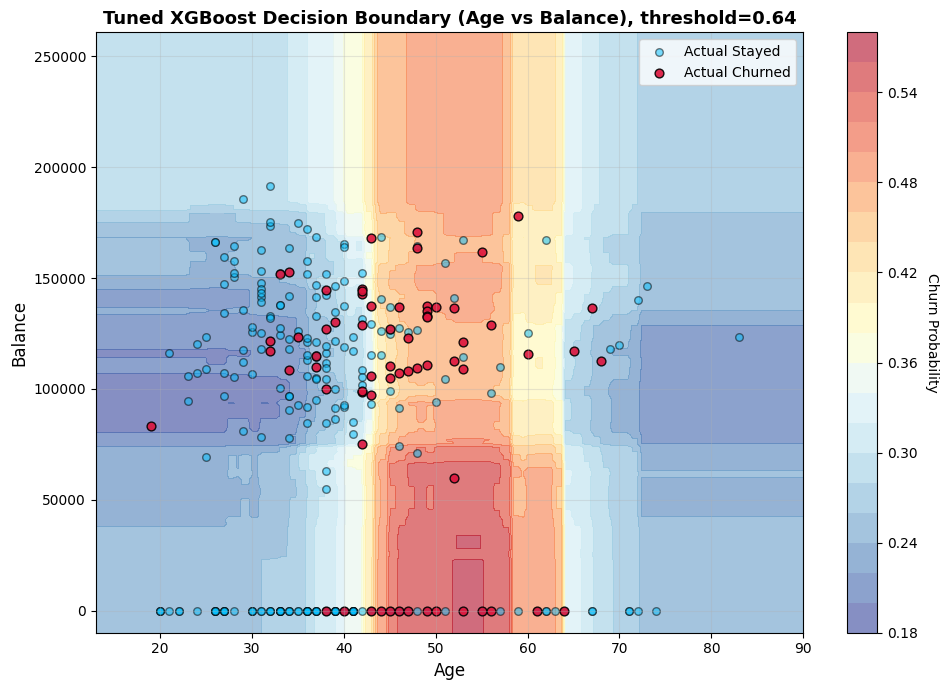

In [ ]:
import joblib

In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 10.7 MB/s eta 0:00:00


In [ ]:
import os
import joblib
import kagglehub
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import TPESampler

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, average_precision_score, f1_score
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42


# Load data

path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
r = os.path.join(path, 'Customer-Churn-Records.csv')
df = pd.read_csv(r)
df.drop(['Complain', 'RowNumber', 'CustomerId', 'Surname'], inplace=True, axis=1)

y = df['Exited']
df = df.drop(['Exited'], axis=1)


# Feature engineering

df['ZeroBalance'] = (df['Balance'] == 0).astype(int)
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['AgeBucket'] = pd.cut(
    df['Age'], bins=[17, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+']
).astype(str)
df['TenureAgeRatio'] = df['Tenure'] / (df['Age'] + 1)

df['ProductsPerTenure'] = df['NumOfProducts'] / (df['Tenure'] + 1)

numeric_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'EstimatedSalary', 'Point Earned', 'BalanceSalaryRatio',
    'TenureAgeRatio', 'ProductsPerTenure'
]
onehot_cols = ['Geography', 'Gender', 'AgeBucket']
ordinal_cols = ['Card Type']


# Stratified split (train / validation / test)

xtr_full, xts, ytr_full, yts = train_test_split(
    df, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
xtr, xval, ytr, yval = train_test_split(
    xtr_full, ytr_full, test_size=0.2, stratify=ytr_full, random_state=RANDOM_STATE
)

num_neg = np.sum(ytr == 0)
num_pos = np.sum(ytr == 1)
estimated_weight = num_neg / num_pos


# Define ColumnTransformer preprocessor

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), onehot_cols),
        ('ord', OrdinalEncoder(categories=[['SILVER', 'GOLD', 'PLATINUM', 'DIAMOND']], handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols)
    ],
    remainder='passthrough'
)


# Hyperparameter search with Optuna (Using Pipeline)
# NOTE: Only xtr/ytr (via StratifiedKFold CV) are used here. xval and xts
# are never touched during tuning, satisfying the test-set separation guideline.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    xgb_params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [150, 250, 350, 500]),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 3.0),
        'scale_pos_weight': estimated_weight,
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'random_state': RANDOM_STATE,
        'n_jobs': -1
    }

    f1_scores = []
    for train_idx, val_idx in cv.split(xtr, ytr):
        X_train_cv, X_val_cv = xtr.iloc[train_idx], xtr.iloc[val_idx]
        y_train_cv, y_val_cv = ytr.iloc[train_idx], ytr.iloc[val_idx]

        pipeline_cv = Pipeline([
            ('preprocessor', preprocessor),
            ('xgb', xgb.XGBClassifier(**xgb_params))
        ])

        pipeline_cv.fit(X_train_cv, y_train_cv)

        preds = pipeline_cv.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, preds))

    return np.mean(f1_scores)

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE)
)

print("Starting Optuna optimization using Pipeline...")
study.optimize(objective, n_trials=60, show_progress_bar=True)

print(f"Best CV F1 Score: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)


# Fit final Pipeline on entire training set (xtr, ytr)

best_params = study.best_params.copy()
best_params.update({
    'scale_pos_weight': estimated_weight,
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'random_state': RANDOM_STATE,
    'n_jobs': -1
})

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb.XGBClassifier(**best_params))
])

final_pipeline.fit(xtr, ytr)


# Final evaluation on test set
# Direct prediction using the pipeline's default 0.5 threshold — xts/yts are
# used here for the first and only time, strictly for final evaluation.

ypr = final_pipeline.predict(xts)
test_proba = final_pipeline.predict_proba(xts)[:, 1]

print(f"\nFinal Test PR-AUC: {average_precision_score(yts, test_proba):.4f}")
print(f"Final Test F1 (default threshold): {f1_score(yts, ypr):.4f}")
print(classification_report(yts, ypr, target_names=["Stayed (0)", "Churned (1)"]))


# Save model pipeline with joblib

model_data = {
    'pipeline': final_pipeline
}

# Export using joblib
joblib.dump(model_data, 'bank_churn_pipeline.joblib')

print("Pipeline saved to 'bank_churn_pipeline.joblib' successfully!")

100%|██████████| 307k/307k [00:00<00:00, 449kB/s]

Extracting files...


Starting Optuna optimization using Pipeline...


  0%|          | 0/60 [00:00<?, ?it/s]

[W 2026-08-20 10:19:10,999] Trial 10 failed with parameters: {'n_estimators': 350, 'learning_rate': 0.02310615453630508, 'max_depth': 8, 'min_child_weight': 7, 'subsample': 0.8262452362725613, 'colsample_bytree': 0.6916416289600302, 'colsample_bylevel': 0.97988537297271, 'gamma': 0.965973771020998, 'reg_alpha': 0.6268836449065679, 'reg_lambda': 2.984725330920674} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_913/468323049.py", line 115, in objective
    pipeline_cv.fit(X_train_cv, y_train_cv)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, i

KeyboardInterrupt: 

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 20.1 MB/s eta 0:00:00


In [ ]:
import os
import joblib
import kagglehub
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

from scipy import stats
from scipy.stats import pointbiserialr, mannwhitneyu, chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="muted")
DPI = 300

TARGET = "Exited"
CONTINUOUS_COLS = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary", "Point Earned"]
DISCRETE_NUMERIC_COLS = ["NumOfProducts"]
NUMERIC_COLS = CONTINUOUS_COLS + DISCRETE_NUMERIC_COLS
CATEGORICAL_COLS = ["Geography", "Gender", "HasCrCard", "IsActiveMember", "Card Type"]

# ============================================================
# Load data
# ============================================================

path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
r = os.path.join(path, 'Customer-Churn-Records.csv')
df = pd.read_csv(r)
df.drop(['Complain', 'RowNumber', 'CustomerId', 'Surname'], inplace=True, axis=1)

y = df['Exited']
df = df.drop(['Exited'], axis=1)

# Stratified split (train / validation / test)
xtr_full, xts, ytr_full, yts = train_test_split(
    df, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
xtr, xval, ytr, yval = train_test_split(
    xtr_full, ytr_full, test_size=0.2, stratify=ytr_full, random_state=RANDOM_STATE
)

# ============================================================
# EXPLORATORY DATA ANALYSIS (TRAIN SPLIT ONLY)
# ============================================================

def eda_target_distribution(ytr: pd.Series) -> pd.DataFrame:
    counts = ytr.value_counts().sort_index()
    pct = (ytr.value_counts(normalize=True).sort_index() * 100).round(2)
    summary = pd.DataFrame({"count": counts, "pct": pct})
    summary.index = ["Stayed (0)", "Churned (1)"]
    return summary

def eda_numeric_univariate(eda_df: pd.DataFrame, numeric_cols=NUMERIC_COLS, target=TARGET):
    desc = eda_df[numeric_cols].describe().T
    desc["IQR"] = desc["75%"] - desc["25%"]
    desc["skew"] = eda_df[numeric_cols].skew()
    desc["kurtosis"] = eda_df[numeric_cols].kurt()

    outlier_summary = {}
    for col in numeric_cols:
        q1, q3 = eda_df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        iqr_outliers = ((eda_df[col] < lower) | (eda_df[col] > upper)).sum()

        z = np.abs(stats.zscore(eda_df[col]))
        z_outliers = int((z > 3).sum())

        outlier_summary[col] = {
            "IQR_outliers": int(iqr_outliers),
            "IQR_outlier_pct": round(100 * iqr_outliers / len(eda_df), 2),
            "Zscore_outliers(>3)": z_outliers,
        }
    outlier_df = pd.DataFrame(outlier_summary).T

    n_cols = 3
    n_rows = int(np.ceil(len(numeric_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(numeric_cols):
        sns.histplot(data=eda_df, x=col, hue=target, kde=True, stat="density",
                     common_norm=False, alpha=0.4, ax=axes[i])
        axes[i].set_title(f"{col} distribution by {target}")
    for j in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.savefig("eda_numeric_distributions.png", dpi=DPI, bbox_inches="tight")
    plt.close()

    return desc, outlier_df

def eda_categorical_univariate(eda_df: pd.DataFrame, categorical_cols=CATEGORICAL_COLS):
    pass

def eda_numeric_vs_target(eda_df: pd.DataFrame, numeric_cols=NUMERIC_COLS, target=TARGET) -> pd.DataFrame:
    results = []
    for col in numeric_cols:
        r_pb, p_pb = pointbiserialr(eda_df[target], eda_df[col])

        grp0 = eda_df.loc[eda_df[target] == 0, col]
        grp1 = eda_df.loc[eda_df[target] == 1, col]
        _, p_mw = mannwhitneyu(grp0, grp1, alternative="two-sided")

        results.append({
            "feature": col,
            "point_biserial_r": round(r_pb, 4),
            "pb_p_value": round(p_pb, 6),
            "mannwhitney_p_value": round(p_mw, 6),
            "significant_(p<0.05)": (p_pb < 0.05) or (p_mw < 0.05),
        })
    results_df = pd.DataFrame(results).sort_values("point_biserial_r", key=abs, ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.violinplot(data=eda_df, x=target, y="Age", ax=axes[0])
    axes[0].set_title("Age distribution by churn (violin)")
    sns.kdeplot(data=eda_df, x="CreditScore", hue=target, fill=True, common_norm=False, ax=axes[1])
    axes[1].set_title("CreditScore density by churn (KDE)")
    plt.tight_layout()
    plt.savefig("eda_numeric_vs_target.png", dpi=DPI, bbox_inches="tight")
    plt.close()

    return results_df

def cramers_v(confusion_matrix: pd.DataFrame) -> float:
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    r, k = confusion_matrix.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return float(np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1))))

def eda_categorical_vs_target(eda_df: pd.DataFrame, categorical_cols=CATEGORICAL_COLS, target=TARGET) -> pd.DataFrame:
    results = []
    for col in categorical_cols:
        ct = pd.crosstab(eda_df[col], eda_df[target])
        chi2, p, _, _ = chi2_contingency(ct)
        v = cramers_v(ct)
        results.append({
            "feature": col,
            "chi2": round(chi2, 3),
            "p_value": round(p, 6),
            "cramers_v": round(v, 4),
            "significant_(p<0.05)": p < 0.05,
        })
    results_df = pd.DataFrame(results).sort_values("cramers_v", ascending=False)

    n_cols = 2
    n_rows = int(np.ceil(len(categorical_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(categorical_cols):
        sns.barplot(data=eda_df, x=col, y=target, ax=axes[i], errorbar=("ci", 95), estimator=np.mean)
        axes[i].set_title(f"Churn rate by {col} (95% CI)")
        axes[i].set_ylabel("Churn rate")
    for j in range(len(categorical_cols), len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.savefig("eda_categorical_vs_target.png", dpi=DPI, bbox_inches="tight")
    plt.close()

    return results_df

def eda_multivariate_interactions(eda_df: pd.DataFrame, target=TARGET):
    geo_gender = eda_df.pivot_table(index="Geography", columns="Gender", values=target, aggfunc="mean")
    zero_balance = (eda_df["Balance"] == 0).astype(int)
    active_zero = (eda_df.assign(ZeroBalance=zero_balance)
                   .pivot_table(index="IsActiveMember", columns="ZeroBalance", values=target, aggfunc="mean"))
    balance_tier = np.where(eda_df["Balance"] == 0, "Zero", "NonZero")
    products_balance = (eda_df.assign(BalanceTier=balance_tier)
                         .pivot_table(index="NumOfProducts", columns="BalanceTier", values=target, aggfunc="mean"))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.heatmap(geo_gender, annot=True, fmt=".2f", cmap="rocket_r", ax=axes[0])
    axes[0].set_title("Churn: Geography x Gender")

    sns.heatmap(active_zero, annot=True, fmt=".2f", cmap="rocket_r", ax=axes[1])
    axes[1].set_title("Churn: IsActiveMember x ZeroBalance")

    sns.heatmap(products_balance, annot=True, fmt=".2f", cmap="rocket_r", ax=axes[2])
    axes[2].set_title("Churn: NumOfProducts x BalanceTier")

    plt.tight_layout()
    plt.savefig("eda_multivariate_interactions.png", dpi=DPI, bbox_inches="tight")
    plt.close()

def eda_correlation_multicollinearity(eda_df: pd.DataFrame, numeric_cols=NUMERIC_COLS, target=TARGET):
    corr_cols = numeric_cols + [target]
    pearson_corr = eda_df[corr_cols].corr(method="pearson")
    spearman_corr = eda_df[corr_cols].corr(method="spearman")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title("Pearson correlation (linear)")
    sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title("Spearman correlation (rank / monotonic)")
    plt.tight_layout()
    plt.savefig("eda_correlation_heatmaps.png", dpi=DPI, bbox_inches="tight")
    plt.close()

    vif_df = eda_df[numeric_cols].dropna()
    X_vif = add_constant(vif_df)
    vif_data = pd.DataFrame({
        "feature": X_vif.columns,
        "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
    })
    vif_data = vif_data[vif_data["feature"] != "const"].sort_values("VIF", ascending=False)

    return pearson_corr, spearman_corr, vif_data

def eda_statistical_summary(numeric_results_df: pd.DataFrame, categorical_results_df: pd.DataFrame) -> pd.DataFrame:
    num_rank = numeric_results_df[["feature", "point_biserial_r"]].copy()
    num_rank["effect_size"] = num_rank["point_biserial_r"].abs()
    num_rank["type"] = "numeric"
    num_rank = num_rank.rename(columns={"point_biserial_r": "stat"})[["feature", "type", "stat", "effect_size"]]

    cat_rank = categorical_results_df[["feature", "cramers_v"]].copy()
    cat_rank["effect_size"] = cat_rank["cramers_v"]
    cat_rank["type"] = "categorical"
    cat_rank = cat_rank.rename(columns={"cramers_v": "stat"})[["feature", "type", "stat", "effect_size"]]

    combined = pd.concat([num_rank, cat_rank], ignore_index=True).sort_values("effect_size", ascending=False)
    combined.insert(0, "rank", range(1, len(combined) + 1))
    return combined

def run_full_eda(xtr: pd.DataFrame, ytr: pd.Series) -> pd.DataFrame:
    eda_df = xtr.copy()
    eda_df[TARGET] = ytr.values

    eda_target_distribution(ytr)
    eda_numeric_univariate(eda_df)
    eda_categorical_univariate(eda_df)
    numeric_results = eda_numeric_vs_target(eda_df)
    categorical_results = eda_categorical_vs_target(eda_df)
    eda_multivariate_interactions(eda_df)
    eda_correlation_multicollinearity(eda_df)
    eda_statistical_summary(numeric_results, categorical_results)

    return eda_df

eda_df = run_full_eda(xtr, ytr)

# ============================================================
# Feature engineering
# ============================================================

def add_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    data['ZeroBalance'] = (data['Balance'] == 0).astype(int)
    data['BalanceSalaryRatio'] = data['Balance'] / (data['EstimatedSalary'] + 1)
    data['AgeBucket'] = pd.cut(
        data['Age'], bins=[17, 30, 40, 50, 60, 100],
        labels=['18-30', '31-40', '41-50', '51-60', '60+']
    ).astype(str)
    data['TenureAgeRatio'] = data['Tenure'] / (data['Age'] + 1)
    data['ProductsPerTenure'] = data['NumOfProducts'] / (data['Tenure'] + 1)

    data['HighRiskProductCount'] = (data['NumOfProducts'] >= 3).astype(int)
    data['InactiveWithBalance'] = (
        (data['IsActiveMember'] == 0) & (data['Balance'] > 0)
    ).astype(int)
    data['InactiveNoCard'] = (
        (data['IsActiveMember'] == 0) & (data['HasCrCard'] == 0)
    ).astype(int)
    data['CreditScoreBucket'] = pd.cut(
        data['CreditScore'], bins=[0, 580, 670, 740, 800, 900],
        labels=['Poor', 'Fair', 'Good', 'VeryGood', 'Excellent']
    ).astype(str)
    data['SalaryPerProduct'] = data['EstimatedSalary'] / (data['NumOfProducts'] + 1)
    return data

xtr = add_features(xtr)
xval = add_features(xval)
xts = add_features(xts)

numeric_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'EstimatedSalary', 'Point Earned', 'BalanceSalaryRatio',
    'TenureAgeRatio', 'ProductsPerTenure', 'SalaryPerProduct'
]
onehot_cols = ['Geography', 'Gender', 'AgeBucket', 'CreditScoreBucket']
ordinal_cols = ['Card Type']

num_neg = np.sum(ytr == 0)
num_pos = np.sum(ytr == 1)
estimated_weight = num_neg / num_pos

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), onehot_cols),
        ('ord', OrdinalEncoder(categories=[['SILVER', 'GOLD', 'PLATINUM', 'DIAMOND']], handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols)
    ],
    remainder='passthrough'
)

# Hyperparameter search with Optuna
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    cb_params = {
        'iterations': trial.suggest_categorical('iterations', [300, 500, 800]),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.0, 2.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, estimated_weight * 1.5),
        'loss_function': 'Logloss',
        'eval_metric': 'F1',
        'random_seed': RANDOM_STATE,
        'verbose': False,
        'allow_writing_files': False,
        'thread_count': -1
    }

    f1_scores = []
    for train_idx, val_idx in cv.split(xtr, ytr):
        X_train_cv, X_val_cv = xtr.iloc[train_idx], xtr.iloc[val_idx]
        y_train_cv, y_val_cv = ytr.iloc[train_idx], ytr.iloc[val_idx]

        pipeline_cv = Pipeline([
            ('preprocessor', preprocessor),
            ('catboost', CatBoostClassifier(**cb_params))
        ])

        pipeline_cv.fit(X_train_cv, y_train_cv)

        preds = pipeline_cv.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, preds))

    return np.mean(f1_scores)

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE)
)

study.optimize(objective, n_trials=60, show_progress_bar=False)

print(f"Best CV F1 Score: {study.best_value:.4f}")

# Fit final Pipeline on entire training set (xtr, ytr)
best_params = study.best_params.copy()
best_params.update({
    'loss_function': 'Logloss',
    'eval_metric': 'F1',
    'random_seed': RANDOM_STATE,
    'verbose': False,
    'allow_writing_files': False,
    'thread_count': -1
})

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('catboost', CatBoostClassifier(**best_params))
])

final_pipeline.fit(xtr, ytr)

# Final evaluation on test set
ypr = final_pipeline.predict(xts)

print(f"Final Test F1 (default threshold): {f1_score(yts, ypr):.4f}")

# Save model pipeline with joblib
model_data = {
    'pipeline': final_pipeline
}

joblib.dump(model_data, 'bank_churn_catboost_pipeline.joblib')

ModuleNotFoundError: No module named 'catboost'

In [ ]:
import os
import joblib
import kagglehub
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

from scipy import stats
from scipy.stats import pointbiserialr, mannwhitneyu, chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="muted")
DPI = 300

TARGET = "Exited"
CONTINUOUS_COLS = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary", "Point Earned"]
DISCRETE_NUMERIC_COLS = ["NumOfProducts"]
NUMERIC_COLS = CONTINUOUS_COLS + DISCRETE_NUMERIC_COLS
CATEGORICAL_COLS = ["Geography", "Gender", "HasCrCard", "IsActiveMember", "Card Type"]

# ============================================================
# Load data
# ============================================================

path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
r = os.path.join(path, 'Customer-Churn-Records.csv')
df = pd.read_csv(r)
df.drop(['Complain', 'RowNumber', 'CustomerId', 'Surname'], inplace=True, axis=1)

y = df['Exited']
df = df.drop(['Exited'], axis=1)

# Stratified split (train / validation / test)
xtr_full, xts, ytr_full, yts = train_test_split(
    df, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
xtr, xval, ytr, yval = train_test_split(
    xtr_full, ytr_full, test_size=0.2, stratify=ytr_full, random_state=RANDOM_STATE
)

# ============================================================
# EXPLORATORY DATA ANALYSIS (TRAIN SPLIT ONLY)
# ============================================================

def eda_target_distribution(ytr: pd.Series) -> pd.DataFrame:
    counts = ytr.value_counts().sort_index()
    pct = (ytr.value_counts(normalize=True).sort_index() * 100).round(2)
    summary = pd.DataFrame({"count": counts, "pct": pct})
    summary.index = ["Stayed (0)", "Churned (1)"]
    return summary

def eda_numeric_univariate(eda_df: pd.DataFrame, numeric_cols=NUMERIC_COLS, target=TARGET):
    desc = eda_df[numeric_cols].describe().T
    desc["IQR"] = desc["75%"] - desc["25%"]
    desc["skew"] = eda_df[numeric_cols].skew()
    desc["kurtosis"] = eda_df[numeric_cols].kurt()

    outlier_summary = {}
    for col in numeric_cols:
        q1, q3 = eda_df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        iqr_outliers = ((eda_df[col] < lower) | (eda_df[col] > upper)).sum()

        z = np.abs(stats.zscore(eda_df[col]))
        z_outliers = int((z > 3).sum())

        outlier_summary[col] = {
            "IQR_outliers": int(iqr_outliers),
            "IQR_outlier_pct": round(100 * iqr_outliers / len(eda_df), 2),
            "Zscore_outliers(>3)": z_outliers,
        }
    outlier_df = pd.DataFrame(outlier_summary).T

    n_cols = 3
    n_rows = int(np.ceil(len(numeric_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(numeric_cols):
        sns.histplot(data=eda_df, x=col, hue=target, kde=True, stat="density",
                     common_norm=False, alpha=0.4, ax=axes[i])
        axes[i].set_title(f"{col} distribution by {target}")
    for j in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.savefig("eda_numeric_distributions.png", dpi=DPI, bbox_inches="tight")
    plt.close()

    return desc, outlier_df

def eda_categorical_univariate(eda_df: pd.DataFrame, categorical_cols=CATEGORICAL_COLS):
    pass

def eda_numeric_vs_target(eda_df: pd.DataFrame, numeric_cols=NUMERIC_COLS, target=TARGET) -> pd.DataFrame:
    results = []
    for col in numeric_cols:
        r_pb, p_pb = pointbiserialr(eda_df[target], eda_df[col])

        grp0 = eda_df.loc[eda_df[target] == 0, col]
        grp1 = eda_df.loc[eda_df[target] == 1, col]
        _, p_mw = mannwhitneyu(grp0, grp1, alternative="two-sided")

        results.append({
            "feature": col,
            "point_biserial_r": round(r_pb, 4),
            "pb_p_value": round(p_pb, 6),
            "mannwhitney_p_value": round(p_mw, 6),
            "significant_(p<0.05)": (p_pb < 0.05) or (p_mw < 0.05),
        })
    results_df = pd.DataFrame(results).sort_values("point_biserial_r", key=abs, ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.violinplot(data=eda_df, x=target, y="Age", ax=axes[0])
    axes[0].set_title("Age distribution by churn (violin)")
    sns.kdeplot(data=eda_df, x="CreditScore", hue=target, fill=True, common_norm=False, ax=axes[1])
    axes[1].set_title("CreditScore density by churn (KDE)")
    plt.tight_layout()
    plt.savefig("eda_numeric_vs_target.png", dpi=DPI, bbox_inches="tight")
    plt.close()

    return results_df

def cramers_v(confusion_matrix: pd.DataFrame) -> float:
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    r, k = confusion_matrix.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return float(np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1))))

def eda_categorical_vs_target(eda_df: pd.DataFrame, categorical_cols=CATEGORICAL_COLS, target=TARGET) -> pd.DataFrame:
    results = []
    for col in categorical_cols:
        ct = pd.crosstab(eda_df[col], eda_df[target])
        chi2, p, _, _ = chi2_contingency(ct)
        v = cramers_v(ct)
        results.append({
            "feature": col,
            "chi2": round(chi2, 3),
            "p_value": round(p, 6),
            "cramers_v": round(v, 4),
            "significant_(p<0.05)": p < 0.05,
        })
    results_df = pd.DataFrame(results).sort_values("cramers_v", ascending=False)

    n_cols = 2
    n_rows = int(np.ceil(len(categorical_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(categorical_cols):
        sns.barplot(data=eda_df, x=col, y=target, ax=axes[i], errorbar=("ci", 95), estimator=np.mean)
        axes[i].set_title(f"Churn rate by {col} (95% CI)")
        axes[i].set_ylabel("Churn rate")
    for j in range(len(categorical_cols), len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.savefig("eda_categorical_vs_target.png", dpi=DPI, bbox_inches="tight")
    plt.close()

    return results_df

def eda_multivariate_interactions(eda_df: pd.DataFrame, target=TARGET):
    geo_gender = eda_df.pivot_table(index="Geography", columns="Gender", values=target, aggfunc="mean")
    zero_balance = (eda_df["Balance"] == 0).astype(int)
    active_zero = (eda_df.assign(ZeroBalance=zero_balance)
                   .pivot_table(index="IsActiveMember", columns="ZeroBalance", values=target, aggfunc="mean"))
    balance_tier = np.where(eda_df["Balance"] == 0, "Zero", "NonZero")
    products_balance = (eda_df.assign(BalanceTier=balance_tier)
                         .pivot_table(index="NumOfProducts", columns="BalanceTier", values=target, aggfunc="mean"))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.heatmap(geo_gender, annot=True, fmt=".2f", cmap="rocket_r", ax=axes[0])
    axes[0].set_title("Churn: Geography x Gender")

    sns.heatmap(active_zero, annot=True, fmt=".2f", cmap="rocket_r", ax=axes[1])
    axes[1].set_title("Churn: IsActiveMember x ZeroBalance")

    sns.heatmap(products_balance, annot=True, fmt=".2f", cmap="rocket_r", ax=axes[2])
    axes[2].set_title("Churn: NumOfProducts x BalanceTier")

    plt.tight_layout()
    plt.savefig("eda_multivariate_interactions.png", dpi=DPI, bbox_inches="tight")
    plt.close()

def eda_correlation_multicollinearity(eda_df: pd.DataFrame, numeric_cols=NUMERIC_COLS, target=TARGET):
    corr_cols = numeric_cols + [target]
    pearson_corr = eda_df[corr_cols].corr(method="pearson")
    spearman_corr = eda_df[corr_cols].corr(method="spearman")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title("Pearson correlation (linear)")
    sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title("Spearman correlation (rank / monotonic)")
    plt.tight_layout()
    plt.savefig("eda_correlation_heatmaps.png", dpi=DPI, bbox_inches="tight")
    plt.close()

    vif_df = eda_df[numeric_cols].dropna()
    X_vif = add_constant(vif_df)
    vif_data = pd.DataFrame({
        "feature": X_vif.columns,
        "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
    })
    vif_data = vif_data[vif_data["feature"] != "const"].sort_values("VIF", ascending=False)

    return pearson_corr, spearman_corr, vif_data

def eda_statistical_summary(numeric_results_df: pd.DataFrame, categorical_results_df: pd.DataFrame) -> pd.DataFrame:
    num_rank = numeric_results_df[["feature", "point_biserial_r"]].copy()
    num_rank["effect_size"] = num_rank["point_biserial_r"].abs()
    num_rank["type"] = "numeric"
    num_rank = num_rank.rename(columns={"point_biserial_r": "stat"})[["feature", "type", "stat", "effect_size"]]

    cat_rank = categorical_results_df[["feature", "cramers_v"]].copy()
    cat_rank["effect_size"] = cat_rank["cramers_v"]
    cat_rank["type"] = "categorical"
    cat_rank = cat_rank.rename(columns={"cramers_v": "stat"})[["feature", "type", "stat", "effect_size"]]

    combined = pd.concat([num_rank, cat_rank], ignore_index=True).sort_values("effect_size", ascending=False)
    combined.insert(0, "rank", range(1, len(combined) + 1))
    return combined

def run_full_eda(xtr: pd.DataFrame, ytr: pd.Series) -> pd.DataFrame:
    eda_df = xtr.copy()
    eda_df[TARGET] = ytr.values

    eda_target_distribution(ytr)
    eda_numeric_univariate(eda_df)
    eda_categorical_univariate(eda_df)
    numeric_results = eda_numeric_vs_target(eda_df)
    categorical_results = eda_categorical_vs_target(eda_df)
    eda_multivariate_interactions(eda_df)
    eda_correlation_multicollinearity(eda_df)
    eda_statistical_summary(numeric_results, categorical_results)

    return eda_df

eda_df = run_full_eda(xtr, ytr)

# ============================================================
# Feature engineering
# ============================================================

def add_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    data['ZeroBalance'] = (data['Balance'] == 0).astype(int)
    data['BalanceSalaryRatio'] = data['Balance'] / (data['EstimatedSalary'] + 1)
    data['AgeBucket'] = pd.cut(
        data['Age'], bins=[17, 30, 40, 50, 60, 100],
        labels=['18-30', '31-40', '41-50', '51-60', '60+']
    ).astype(str)
    data['TenureAgeRatio'] = data['Tenure'] / (data['Age'] + 1)
    data['ProductsPerTenure'] = data['NumOfProducts'] / (data['Tenure'] + 1)

    data['HighRiskProductCount'] = (data['NumOfProducts'] >= 3).astype(int)
    data['InactiveWithBalance'] = (
        (data['IsActiveMember'] == 0) & (data['Balance'] > 0)
    ).astype(int)
    data['InactiveNoCard'] = (
        (data['IsActiveMember'] == 0) & (data['HasCrCard'] == 0)
    ).astype(int)
    data['CreditScoreBucket'] = pd.cut(
        data['CreditScore'], bins=[0, 580, 670, 740, 800, 900],
        labels=['Poor', 'Fair', 'Good', 'VeryGood', 'Excellent']
    ).astype(str)
    data['SalaryPerProduct'] = data['EstimatedSalary'] / (data['NumOfProducts'] + 1)
    return data

xtr = add_features(xtr)
xval = add_features(xval)
xts = add_features(xts)

numeric_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'EstimatedSalary', 'Point Earned', 'BalanceSalaryRatio',
    'TenureAgeRatio', 'ProductsPerTenure', 'SalaryPerProduct'
]
onehot_cols = ['Geography', 'Gender', 'AgeBucket', 'CreditScoreBucket']
ordinal_cols = ['Card Type']

num_neg = np.sum(ytr == 0)
num_pos = np.sum(ytr == 1)
estimated_weight = num_neg / num_pos

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), onehot_cols),
        ('ord', OrdinalEncoder(categories=[['SILVER', 'GOLD', 'PLATINUM', 'DIAMOND']], handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols)
    ],
    remainder='passthrough'
)

# Hyperparameter search with Optuna
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    cb_params = {
        'iterations': trial.suggest_categorical('iterations', [300, 500, 800]),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.0, 2.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, estimated_weight * 1.5),
        'loss_function': 'Logloss',
        'eval_metric': 'F1',
        'random_seed': RANDOM_STATE,
        'verbose': False,
        'allow_writing_files': False,
        'thread_count': -1
    }

    f1_scores = []
    for train_idx, val_idx in cv.split(xtr, ytr):
        X_train_cv, X_val_cv = xtr.iloc[train_idx], xtr.iloc[val_idx]
        y_train_cv, y_val_cv = ytr.iloc[train_idx], ytr.iloc[val_idx]

        pipeline_cv = Pipeline([
            ('preprocessor', preprocessor),
            ('catboost', CatBoostClassifier(**cb_params))
        ])

        pipeline_cv.fit(X_train_cv, y_train_cv)

        preds = pipeline_cv.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, preds))

    return np.mean(f1_scores)

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE)
)

study.optimize(objective, n_trials=60, show_progress_bar=False)

print(f"Best CV F1 Score: {study.best_value:.4f}")

# Fit final Pipeline on entire training set (xtr, ytr)
best_params = study.best_params.copy()
best_params.update({
    'loss_function': 'Logloss',
    'eval_metric': 'F1',
    'random_seed': RANDOM_STATE,
    'verbose': False,
    'allow_writing_files': False,
    'thread_count': -1
})

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('catboost', CatBoostClassifier(**best_params))
])

final_pipeline.fit(xtr, ytr)

# Final evaluation on test set
ypr = final_pipeline.predict(xts)

print(f"Final Test F1 (default threshold): {f1_score(yts, ypr):.4f}")

# Save model pipeline with joblib
model_data = {
    'pipeline': final_pipeline
}

joblib.dump(model_data, 'bank_churn_catboost_pipeline.joblib')

100%|██████████| 307k/307k [00:00<00:00, 25.2MB/s]

Extracting files...


Best CV F1 Score: 0.6188
Final Test F1 (default threshold): 0.6190


['bank_churn_pipeline.joblib']

In [ ]:
import os
import joblib
import kagglehub
import numpy as np
import pandas as pd
import optuna
from optuna.samplers import TPESampler
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, average_precision_score, f1_score
)
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42


# Load data

path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
r = os.path.join(path, 'Customer-Churn-Records.csv')
df = pd.read_csv(r)
df.drop(['Complain', 'RowNumber', 'CustomerId', 'Surname'], inplace=True, axis=1)

y = df['Exited']
df = df.drop(['Exited'], axis=1)


# Feature engineering (identical to the XGBoost pipeline, for a fair comparison)

df['ZeroBalance'] = (df['Balance'] == 0).astype(int)
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['AgeBucket'] = pd.cut(
    df['Age'], bins=[17, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+']
).astype(str)
df['TenureAgeRatio'] = df['Tenure'] / (df['Age'] + 1)
df['ProductsPerTenure'] = df['NumOfProducts'] / (df['Tenure'] + 1)

# CatBoost takes raw categoricals directly — no one-hot / ordinal encoding needed.
# We just need them as strings so CatBoost's cat_features handling doesn't choke
# on mixed dtypes (e.g. NumOfProducts as both a numeric feature and category label).
cat_features = ['Geography', 'Gender', 'AgeBucket', 'Card Type']


# Stratified split (train / validation / test) — identical to the XGBoost script

xtr_full, xts, ytr_full, yts = train_test_split(
    df, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
xtr, xval, ytr, yval = train_test_split(
    xtr_full, ytr_full, test_size=0.2, stratify=ytr_full, random_state=RANDOM_STATE
)

num_neg = np.sum(ytr == 0)
num_pos = np.sum(ytr == 1)
estimated_weight = num_neg / num_pos


# Preprocessing
# CatBoost needs categorical columns as strings (not pandas 'category' dtype
# mixed with NaNs) and prefers a plain DataFrame in / DataFrame out step so
# cat_features can be referenced by column name inside the pipeline.

def cast_categoricals(X):
    X = X.copy()
    for c in cat_features:
        X[c] = X[c].astype(str)
    return X

preprocessor = FunctionTransformer(cast_categoricals)


# Hyperparameter search with Optuna (Using Pipeline)
# NOTE: Only xtr/ytr (via StratifiedKFold CV) are used here. xval and xts
# are never touched during tuning, satisfying the test-set separation guideline.
# scale_pos_weight is searched rather than fixed, per the earlier discussion —
# since F1 is locked to the 0.5 threshold, this is the main lever for controlling
# the precision/recall tradeoff.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    cb_params = {
        'iterations': trial.suggest_categorical('iterations', [300, 500, 800, 1200]),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.0, 2.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_categorical('border_count', [32, 64, 128, 254]),
        'scale_pos_weight': trial.suggest_float(
            'scale_pos_weight', 1.0, estimated_weight * 2, log=True
        ),
        'loss_function': 'Logloss',
        'eval_metric': 'F1',
        'random_state': RANDOM_STATE,
        'verbose': False,
        'allow_writing_files': False,
        'thread_count': -1,
    }

    f1_scores = []
    for train_idx, val_idx in cv.split(xtr, ytr):
        X_train_cv, X_val_cv = xtr.iloc[train_idx], xtr.iloc[val_idx]
        y_train_cv, y_val_cv = ytr.iloc[train_idx], ytr.iloc[val_idx]

        pipeline_cv = Pipeline([
            ('preprocessor', preprocessor),
            ('catboost', CatBoostClassifier(cat_features=cat_features, **cb_params))
        ])

        pipeline_cv.fit(X_train_cv, y_train_cv)

        preds = pipeline_cv.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, preds))

    return np.mean(f1_scores)

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE)
)

print("Starting Optuna optimization using Pipeline (CatBoost)...")
study.optimize(objective, n_trials=60, show_progress_bar=True)

print(f"Best CV F1 Score: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)


# Fit final Pipeline on entire training set (xtr, ytr)

best_params = study.best_params.copy()
best_params.update({
    'loss_function': 'Logloss',
    'eval_metric': 'F1',
    'random_state': RANDOM_STATE,
    'verbose': False,
    'allow_writing_files': False,
    'thread_count': -1,
})

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('catboost', CatBoostClassifier(cat_features=cat_features, **best_params))
])

final_pipeline.fit(xtr, ytr)


# Validation check (xval) — use this to compare against the XGBoost model
# BEFORE touching xts. This is the step to run first.

yval_pred = final_pipeline.predict(xval)
print(f"\nValidation F1 (default threshold): {f1_score(yval, yval_pred):.4f}")


# Final evaluation on test set
# Direct prediction using the pipeline's default 0.5 threshold — xts/yts should
# only be used here, once, and only after you've picked the winning model on xval.

ypr = final_pipeline.predict(xts)
test_proba = final_pipeline.predict_proba(xts)[:, 1]

print(f"\nFinal Test PR-AUC: {average_precision_score(yts, test_proba):.4f}")
print(f"Final Test F1 (default threshold): {f1_score(yts, ypr):.4f}")
print(classification_report(yts, ypr, target_names=["Stayed (0)", "Churned (1)"]))


# Save model pipeline with joblib

model_data = {
    'pipeline': final_pipeline
}

joblib.dump(model_data, 'bank_churn_catboost_pipeline.joblib')

print("Pipeline saved to 'bank_churn_catboost_pipeline.joblib' successfully!")